In [1]:
# Developed a machine learning project for customer churn prediction using Logistic Regression, KNN, and Decision Tree algorithms. Performed data preprocessing, feature scaling, model training, and compared model performance using Accuracy, Precision, Recall, and F1-Score metrics.

In [1]:
# Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
# Load Dataset

train = pd.read_csv("customer_churn_dataset-training-master.csv")
test = pd.read_csv("customer_churn_dataset-testing-master.csv")

# Dataset Inspection

print(train.head())

print(train.isnull().sum())

print(train.dtypes)

   CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0         2.0  30.0  Female    39.0             14.0            5.0   
1         3.0  65.0  Female    49.0              1.0           10.0   
2         4.0  55.0  Female    14.0              4.0            6.0   
3         5.0  58.0    Male    38.0             21.0            7.0   
4         6.0  23.0    Male    32.0             20.0            5.0   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0           18.0          Standard          Annual        932.0   
1            8.0             Basic         Monthly        557.0   
2           18.0             Basic       Quarterly        185.0   
3            7.0          Standard         Monthly        396.0   
4            8.0             Basic         Monthly        617.0   

   Last Interaction  Churn  
0              17.0    1.0  
1               6.0    1.0  
2               3.0    1.0  
3              29.0    1.0  
4              20.0    1.

In [3]:
# Handle Missing Values

num_cols = [
    'Age',
    'Tenure',
    'Usage Frequency',
    'Support Calls',
    'Payment Delay',
    'Total Spend',
    'Last Interaction'
]

for col in num_cols:
    train[col].fillna(train[col].mean(), inplace=True)
    test[col].fillna(test[col].mean(), inplace=True)

cat_cols = [
    'Gender',
    'Subscription Type',
    'Contract Length'
]

for col in cat_cols:
    train[col].fillna(train[col].mode()[0], inplace=True)
    test[col].fillna(test[col].mode()[0], inplace=True)

In [4]:
# Fill Missing Target Values

train['Churn'] = train['Churn'].fillna(train['Churn'].mode()[0])

test['Churn'] = test['Churn'].fillna(test['Churn'].mode()[0])

In [5]:
# Drop CustomerID

train = train.drop('CustomerID', axis=1)
test = test.drop('CustomerID', axis=1)

In [6]:
# Label Encoding

le_gender = LabelEncoder()
le_subscription = LabelEncoder()
le_contract = LabelEncoder()

train['Gender'] = le_gender.fit_transform(train['Gender'])
test['Gender'] = le_gender.transform(test['Gender'])

train['Subscription Type'] = le_subscription.fit_transform(train['Subscription Type'])
test['Subscription Type'] = le_subscription.transform(test['Subscription Type'])

train['Contract Length'] = le_contract.fit_transform(train['Contract Length'])
test['Contract Length'] = le_contract.transform(test['Contract Length'])

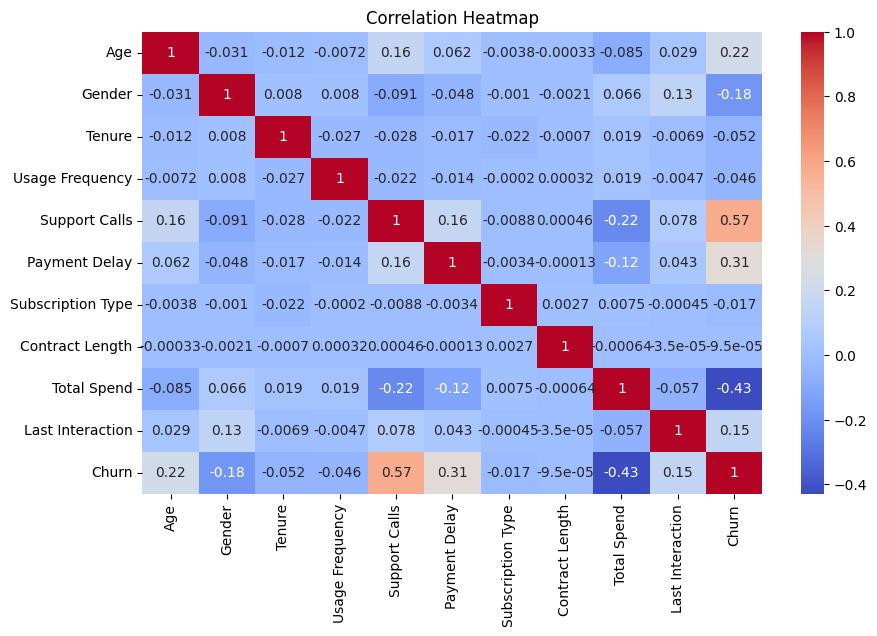

In [7]:
# Correlation Heatmap

plt.figure(figsize=(10,6))

sns.heatmap(
    train.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [8]:
# Split Features and Target

X_train = train.drop('Churn', axis=1)
y_train = train['Churn']

X_test = test.drop('Churn', axis=1)
y_test = test['Churn']

In [9]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
#Model :-

# Logistic Regression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

# KNN

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

# Decision Tree

dt_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [11]:
# Evaluation Function

def evaluate_model(y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(y_true, y_pred)

    recall = recall_score(y_true, y_pred)

    f1 = f1_score(y_true, y_pred)

    return accuracy, precision, recall, f1

In [12]:
# Evaluate Models

lr_results = evaluate_model(y_test, lr_pred)

knn_results = evaluate_model(y_test, knn_pred)

dt_results = evaluate_model(y_test, dt_pred)

In [13]:
# Comparison Table

results_df = pd.DataFrame({

    'Algorithm': [
        'Logistic Regression',
        'KNN',
        'Decision Tree'
    ],

    'Accuracy': [
        lr_results[0],
        knn_results[0],
        dt_results[0]
    ],

    'Precision': [
        lr_results[1],
        knn_results[1],
        dt_results[1]
    ],

    'Recall': [
        lr_results[2],
        knn_results[2],
        dt_results[2]
    ],

    'F1-Score': [
        lr_results[3],
        knn_results[3],
        dt_results[3]
    ]

})

print(results_df)

             Algorithm  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.600972   0.543889  0.976585  0.698669
1                  KNN  0.539037   0.506899  0.986718  0.669738
2        Decision Tree  0.506680   0.489831  0.998393  0.657218


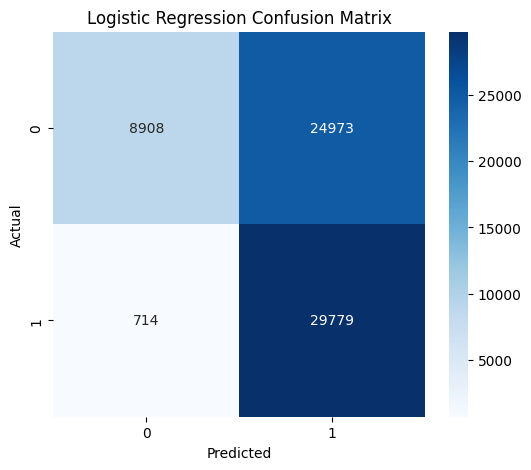

In [14]:
# Confusion Matrix

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [15]:
# Classification Report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.93      0.26      0.41     33881
           1       0.54      0.98      0.70     30493

    accuracy                           0.60     64374
   macro avg       0.73      0.62      0.55     64374
weighted avg       0.74      0.60      0.55     64374



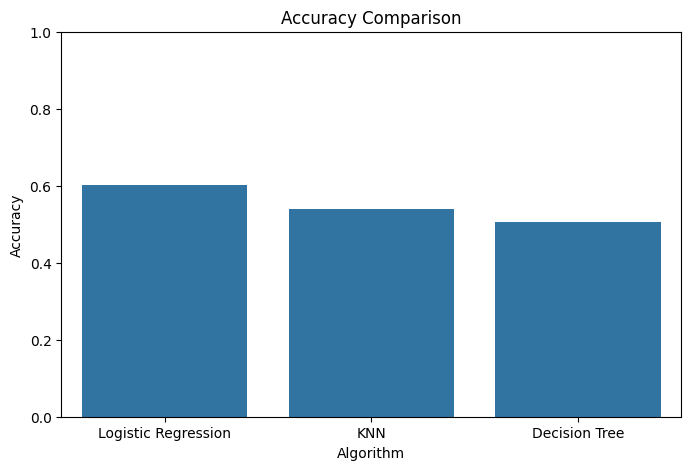

In [16]:
# Accuracy Comparison Graph

plt.figure(figsize=(8,5))

sns.barplot(
    x='Algorithm',
    y='Accuracy',
    data=results_df
)

plt.title("Accuracy Comparison")
plt.ylim(0,1)

plt.show()

In [17]:
# Best Model

best_model = results_df.loc[
    results_df['Accuracy'].idxmax()
]

print(best_model)

Algorithm    Logistic Regression
Accuracy                0.600972
Precision               0.543889
Recall                  0.976585
F1-Score                0.698669
Name: 0, dtype: object
